<a href="https://colab.research.google.com/github/vidhya2432/Machine_Learning/blob/main/ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Step 2: Load dataset
data = pd.read_csv("/content/Iris.csv")

In [ ]:
# Step 3: Separate features and target
X = data.iloc[:, 1:-1].values
y = data.iloc[:, -1].values

In [ ]:
# Step 4: Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [ ]:
# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# -------------------------
# Step 6: Linear Kernel
# -------------------------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, y_pred_linear)

In [ ]:
# -------------------------
# Step 7: Polynomial Kernel
# -------------------------
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, y_pred_poly)

In [ ]:
# -------------------------
# Step 8: RBF Kernel
# -------------------------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

# Step 9: Display results
print("Linear Kernel Accuracy:", acc_linear)
print("Polynomial Kernel Accuracy:", acc_poly)
print("RBF Kernel Accuracy:", acc_rbf)

Linear Kernel Accuracy: 1.0
Polynomial Kernel Accuracy: 1.0
RBF Kernel Accuracy: 1.0


In [ ]:
#------------------------------------------
# Step 9: Train SVM with different kernels
#------------------------------------------
svm_linear = SVC(kernel='linear')
svm_poly = SVC(kernel='poly', degree=3)
svm_rbf = SVC(kernel='rbf')

svm_linear.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)


SVC()

In [ ]:
#----------------------
# Step 10: Predictions
#---------------------
pred_linear = svm_linear.predict(X_test)
pred_poly = svm_poly.predict(X_test)
pred_rbf = svm_rbf.predict(X_test)

In [ ]:
#-------------------
# Step 11: Accuracy
#-------------------
print("Linear Kernel Accuracy:", accuracy_score(y_test, pred_linear))
print("Polynomial Kernel Accuracy:", accuracy_score(y_test, pred_poly))
print("RBF Kernel Accuracy:", accuracy_score(y_test, pred_rbf))

Linear Kernel Accuracy: 1.0
Polynomial Kernel Accuracy: 1.0
RBF Kernel Accuracy: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix

#---------------------------
# Step 12: Confusion Matrix
#---------------------------
print("\nConfusion Matrix (Linear):")
print(confusion_matrix(y_test, pred_linear))

print("\nConfusion Matrix (Polynomial):")
print(confusion_matrix(y_test, pred_poly))

print("\nConfusion Matrix (RBF):")
print(confusion_matrix(y_test, pred_rbf))


Confusion Matrix (Linear):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Confusion Matrix (Polynomial):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Confusion Matrix (RBF):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
#-----------------------------------
# Step 13: Visualization function
#-----------------------------------
def plot_decision_boundary(model, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.title(title)
    plt.show()

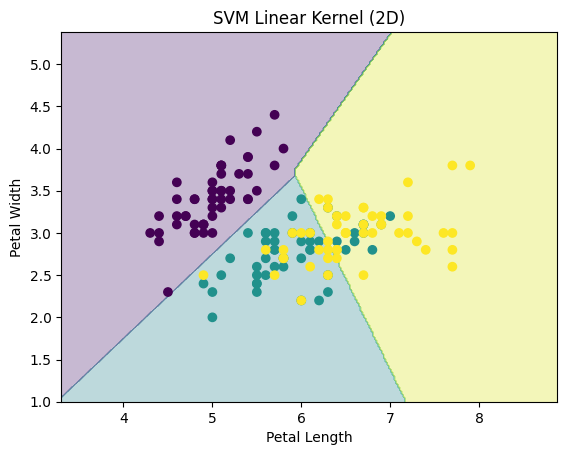

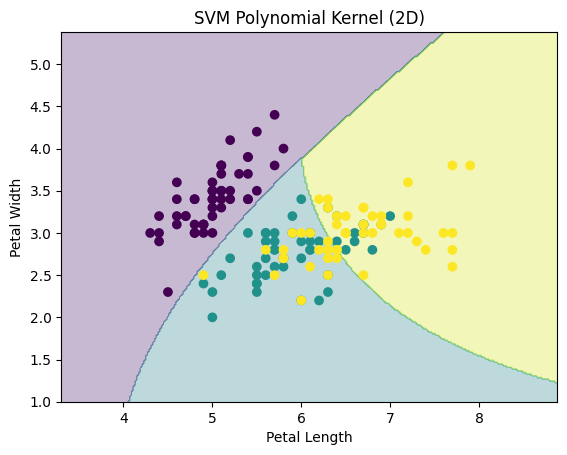

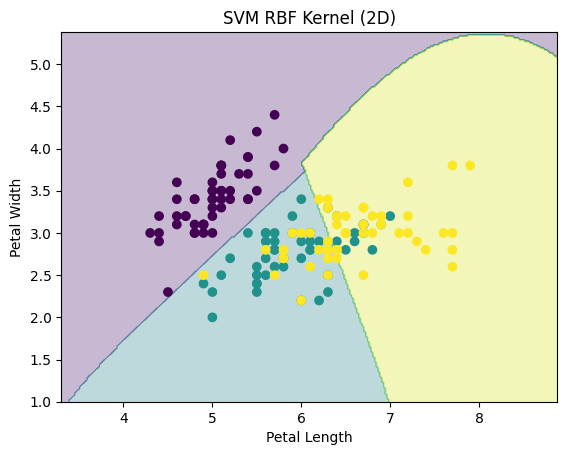

In [ ]:
#----------------------------
# Step 14: Plot boundaries
#----------------------------
import matplotlib.pyplot as plt

# Select the first two features for 2D plotting
X_plot = X[:, :2]  # Assuming the first two features are desired for visualization
y_plot = y

# Split the 2D dataset for training new models for visualization
X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(
    X_plot, y_plot, test_size=0.2, random_state=42
)

# Train new SVM models on the 2D data
svm_linear_2d = SVC(kernel='linear')
svm_linear_2d.fit(X_train_plot, y_train_plot)

svm_poly_2d = SVC(kernel='poly', degree=3)
svm_poly_2d.fit(X_train_plot, y_train_plot)

svm_rbf_2d = SVC(kernel='rbf')
svm_rbf_2d.fit(X_train_plot, y_train_plot)

# Plot decision boundaries using the new 2D models
plot_decision_boundary(svm_linear_2d, "SVM Linear Kernel (2D)")
plot_decision_boundary(svm_poly_2d, "SVM Polynomial Kernel (2D)")
plot_decision_boundary(svm_rbf_2d, "SVM RBF Kernel (2D)")